# Footprint computation

Compute per-position mutual information (MI) and per-base expression shift from RegSeq2 barcode counts, then plot footprints.

- **MI**: how strongly mutations at each position change DNA → RNA enrichment.
- **Expression shift**: signed per-base effect, computed as the deviation of `(RNA+1)/(DNA+1)` from its mean across variants carrying a mutation to that base.
- The footprint plots at the bottom show smoothed MI (with an `a/N` background subtracted) coloured by expression shift.

Pipeline order: setup & metadata → helpers → MI / expression-shift definitions → bulk computation across samples (writes CSVs) → reload & background fit → footprint plots.


In [1]:
import pandas as pd
from glob import glob
import numpy as np
from numba import njit

from matplotlib import font_manager
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy
from scipy.ndimage import gaussian_filter1d
import itertools
import regseq2

from matplotlib.colors import LinearSegmentedColormap, Normalize
import matplotlib.patches as mpatches
from matplotlib.cm import ScalarMappable
from matplotlib import collections  as mc
import matplotlib.colors as mcolors

regseq2.viz.matplotlib_style()
regseq2.viz.my_color_dict

from denovo_scanner import build_wt_dict, run_scan, save_outputs, load_df_map

weight = 'regular'
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Lato"],

    "font.weight": weight,        # ticks, text
    "axes.labelweight": weight,   # axis labels
    "axes.titleweight": weight,   # titles
})


In [2]:
df_gc = pd.read_csv("../../data/metadata/growth_conditions_short.csv", delimiter=";")
print(df_gc.tail(5))

    Index             Condition  \
34     37         low phosphate   
35     38  copper sulfate (2mM)   
36     39               acetate   
37     40               nitrate   
38     41   anaerobic + nitrate   

                                          Description  \
34  M9 Minimal Media with 0.5% Glucose to steady s...   
35  M9 Minimal Media with 0.5% Glucose to steady s...   
36          M9 Minimal Media with 0.5% Sodium Acetate   
37  M9 Minimal Media with 0.5% Glucose with 80mM P...   
38  M9 Minimal Media with 0.5% Glucose grown compl...   

                          Group  
34  Nutrient–mineral limitation  
35      Metal & membrane stress  
36                Carbon‐source  
37       Osmotic & ionic stress  
38                    Anaerobic  


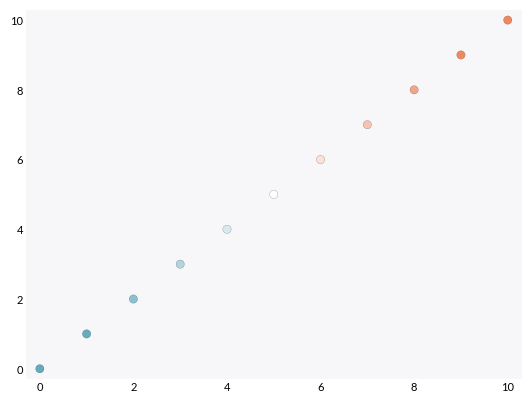

In [3]:
colors_with_points = [
            (0, "#63ACBE"),  
            (0.1, "#63ACBE"),  
            (.5, "#ffffff"),    
            (0.9, "#EF875F"),
            (1, "#EF875F")
        ]


colors_with_points_mi = [
            (0, "#63ACBE"),  
            (0.1, "#63ACBE"),  
            (.5, "#C8C8C8"),    
            (0.9, "#EF875F"),
            (1, "#EF875F")
        ]

my_cmap_mi = LinearSegmentedColormap.from_list("my_cmap", colors_with_points_mi)

my_cmap = LinearSegmentedColormap.from_list("my_cmap", colors_with_points)

plt.scatter(np.arange(11), np.arange(11), color=[my_cmap(x) for x in np.linspace(0, 1, 11)], linewidth=0.1, edgecolor='black')


In [4]:
df_map = pd.read_csv("../../data/mapping/mapped_barcodes_filtered.csv")


# ----------------------------
# Global figure + font settings
# ----------------------------
FIG_WIDTH = 7.0
FIG_HEIGHT = 3.0

mpl.rcParams.update({
    # Figure geometry
    "figure.figsize": (FIG_WIDTH, FIG_HEIGHT),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",

    # Fonts
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,

    # Lines / markers
    "lines.linewidth": 1.2,
    "lines.markersize": 4,

    # Axes styling
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,

    # Mathtext / fonts (no external LaTeX dependency)
    #"mathtext.fontset": "stix",
    #"font.family": "STIXGeneral",
})



In [5]:
df_wt = pd.read_csv("../../data/metadata/wt_sequences.csv")[['promoter_seq', 'promoter']]
wt_dict = dict(zip(df_wt['promoter'].values, df_wt['promoter_seq'].values))
df_wt

,promoter_seq,promoter
0,TTTCATCTTTTGTCAACCATTCACAGCGCAAATATACGCCTTTTTT...,rspAp
1,TCCACATTGATTATTTGCACGGCGTCACACTTTGCTATGCCATAGC...,araBp
2,GTGTTGCACCTCCCCAGAGAGCGGCGGATAATGCTGCGAAAAGAAG...,znuCp
3,CCAGTTTCATCATTCCATTTTATTTTGCGAGCGAGCGCACACTTGT...,xylAp
4,AATTGCGCAACAAAAGTAAGATCTCGGTCATAAATCAAGAAATAAA...,xylFp
...,...,...
112,TGGTGCTGGTTATCAGCACTGAAGGCGACACCGACGTGAAGCACTA...,ygeY_predicted
113,CGCTGGACGAAATCCGCGCCCTGCCTGCAGTACAGAAAGCTAACGC...,hyuA_predicted
114,TCGGACATGTTTGAAGAGATGAAATTTGCCTTCTTTAAACATCGCG...,ygfM_xdhD_predicted
115,AGTGCCAGTTTTTGCGAGGAAGGGGAGTTAGAGACAGGAATTGCGG...,ygfS_ygfT_predicted


In [6]:
# List growth condition indices from the DNA barcode files (each ind = one sample / condition).
files = np.hstack([glob("../../data/extracted_barcodes/*DNA*.txt")])
inds = np.sort([x.split('/')[-1].split('_')[0] for x in files])

# Drop samples that failed QC 
bad_inds = ['14-3', '15-1', '19-1', '22-1', '25-2', '38-2', '4-1', '31-2', '20-2', '13-2', '26-1', '26-2']
inds = [ind for ind in inds if ind not in bad_inds]


## Helpers

`get_counts(ind, promoter)` joins DNA + RNA barcode counts for a given growth condition `ind` with the barcode → promoter map.


In [7]:
def get_counts(ind, promoter=None):
    """Load DNA + RNA barcode counts for sample `ind` and join them with the barcode → promoter map.

    Returns one row per barcode with columns: ct_0 (DNA reads), ct_1 (RNA reads),
    barcode, name (promoter id), promoter (160 nt mutated sequence).

    `promoter` can be None (all promoters), a str, or a list of strs.
    """
    # DNA file: ct_0 is the input library count
    file_DNA = glob(f"../../data/extracted_barcodes/{ind}*DNA*.txt")[0]
    df_DNA = pd.read_csv(
        file_DNA,
        names=['ct_0', 'barcode'], sep="\\s+")
    # RNA file: ct_1 is the readout count
    file_RNA = glob(f"../../data/extracted_barcodes/{ind}*RNA*.txt")[0]
    df_RNA = pd.read_csv(
        file_RNA,
        names=['ct_1', 'barcode'], sep="\\s+")

    # outer-join keeps barcodes seen in either DNA or RNA; inner-join with df_map drops unmapped barcodes
    df_counts = df_DNA.merge(df_RNA, on="barcode", how='outer').fillna(0)
    df_counts = df_counts.merge(df_map, on="barcode", how='inner')

    # filter to requested promoter(s)
    if promoter == None:
        return df_counts
    elif type(promoter) == str:
        return df_counts[df_counts['name'] == promoter]
    elif type(promoter) == list:
        return df_counts[[x in promoter for x in df_counts['name'].values]]


In [9]:
get_counts("36-1", "yjbJ_predicted").to_csv("yjbj_salt_1.csv")

In [10]:
get_counts("36-2", "yjbJ_predicted").to_csv("yjbj_salt_2.csv")

## Mutual information per position

For each position, treat WT/mut as the input and DNA/RNA as the readout, then compute MI from the 2×2 joint distribution of (transformed) read counts.

This is the one notebook where these functions are shown explicitly (for reference/derivation); they're also the canonical implementation in `regseq2.analysis` (src/regseq2/analysis.py), and every other notebook imports them from there instead of redefining them, so there's only ever one version of the math. Keep this section in sync with `regseq2/analysis.py` by hand.

In [ ]:
_EXCLUDED_PROMOTERS = ("galEp", "ybeDp2")


def _transform_counts(c, transform="raw"):
    """Reshape count weights to dampen highly-expressed barcodes.

    "sqrt" / "log1p" / "pow:a" compress dynamic range; "clip:k" caps extreme values.
    """
    c = c.astype(np.float64)
    if transform == "raw":
        return c
    if transform == "sqrt":
        return np.sqrt(c)
    if transform == "log1p":
        return np.log1p(c)
    if transform.startswith("pow:"):
        a = float(transform.split(":")[1])
        return np.power(c, a)
    if transform.startswith("clip:"):
        k = float(transform.split(":")[1])
        return np.minimum(c, k)
    raise ValueError(f"Unknown transform: {transform}")


def _mi_2x2_vectorized(joint):
    """MI in bits for a stack of 2×2 joint distributions, shape (L, 2, 2), each summing to 1.

    Vectorized replacement for calling a per-position MI routine in a Python loop:
    all L positions are computed together with array ops instead of L separate calls.
    """
    px = joint.sum(axis=2)  # (L, 2): P(x) marginal per position
    pz = joint.sum(axis=1)  # (L, 2): P(z) marginal per position
    outer = px[:, :, None] * pz[:, None, :]  # (L, 2, 2): P(x)P(z) under independence
    ratio = np.divide(joint, outer, out=np.ones_like(joint), where=outer > 0)
    terms = np.where((joint > 0) & (outer > 0), joint * np.log2(ratio), 0.0)
    return terms.sum(axis=(1, 2))


def _h2_vectorized(p):
    """Bernoulli entropy in bits, elementwise; `p` may be scalar or array-valued."""
    p = np.asarray(p, dtype=np.float64)
    h = np.zeros_like(p)
    valid = (p > 0) & (p < 1)
    h[valid] = -p[valid] * np.log2(p[valid]) - (1.0 - p[valid]) * np.log2(1.0 - p[valid])
    return h


def _prepare_promoter_arrays(gdf, promoter, *, transform="sqrt", barcode_equal=False, require_both_counts=False):
    """Precompute the per-barcode data for one promoter that is independent of how
    ct_0/ct_1 pairs get assigned to barcodes: the WT-match matrix and the
    (transformed, optionally barcode-equalized) DNA/RNA weight vectors.

    Scrambling only changes which weight-vector entry lines up with which
    `is_match` row (see `_mi_footprint`), so this expensive part — parsing
    sequences, comparing against WT, transforming counts — only needs to run once
    per promoter no matter how many scrambles are drawn from it.

    Parameters
    ----------
    gdf : pandas.DataFrame
        Counts already filtered to a single `promoter` (e.g. one group from
        `df_counts.groupby("name")`, or `df_counts[df_counts["name"] == promoter]`).
    promoter : str
        Name of the promoter `gdf` belongs to (used to look up its WT sequence).

    Returns
    -------
    is_match : (N, L) float64 array
        1.0 where a barcode's sequence matches WT at that position, else 0.0.
        float64 (not int64/bool) so `is_match.T @ x` in `_mi_footprint` takes
        numpy's BLAS-backed matmul path instead of a slow generic one.
    x, y : (N,) float64 arrays
        Transformed (and optionally barcode-equalized) DNA/RNA weights.
    n_seqs : int
        Number of distinct mutated sequences observed for this promoter (unfiltered).
    """
    wt_seq = wt_dict[promoter]
    L = len(wt_seq)

    seqs = gdf["promoter"].astype(str)
    if (seqs.str.len() != L).any():
        raise ValueError(f"all sequences for {promoter} must have length {L}")
    seq_arr = np.frombuffer(
        "".join(seqs.values).encode("ascii"), dtype=np.uint8
    ).reshape(len(seqs), L)
    wt_arr = np.frombuffer(wt_seq.encode("ascii"), dtype=np.uint8)
    is_match = (seq_arr == wt_arr[None, :]).astype(np.float64)

    if require_both_counts:
        idx = (gdf["ct_0"].values > 0) & (gdf["ct_1"].values > 0)
    else:
        idx = np.ones(len(gdf), dtype=bool)

    is_match = is_match[idx, :]
    x = _transform_counts(gdf["ct_0"].values[idx], transform=transform)
    y = _transform_counts(gdf["ct_1"].values[idx], transform=transform)

    if barcode_equal:
        denom = x + y
        denom = np.where(denom > 0, denom, 1.0)
        x = x / denom
        y = y / denom

    n_seqs = gdf["promoter"].nunique()
    return is_match, x, y, n_seqs


def _mi_footprint(is_match, x, y, *, mismatch=None, a=0.0, normalize_by_entropy=False):
    """Core per-position MI computation from a WT-match matrix and DNA/RNA weight
    vectors (see `_prepare_promoter_arrays`). This is the only part that needs to
    be redone for each scramble, since scrambling just reorders/resamples which
    entries of `x`/`y` line up with the (fixed) rows of `is_match`.

    `mismatch` (1 - is_match) can be passed in precomputed when this is called
    repeatedly on the same `is_match` (e.g. once per scramble in
    `compute_MI_null_percentile`) to avoid rebuilding that (N, L) array every call;
    if omitted it's computed fresh, which is fine for a single call.

    Returns
    -------
    (mi, mi_norm, total, N) or None if the total read weight is <= 0.
    """
    L = is_match.shape[1]
    total = np.sum(x + y)
    if total <= 0:
        return None

    if mismatch is None:
        mismatch = 1.0 - is_match

    # Build joint weights per position. Indices: joint[pos, x_state, z]
    #   x_state: 0 = match WT, 1 = mismatch (mutated); z: 0 = DNA, 1 = RNA
    joint = np.zeros((L, 2, 2), dtype=np.float64)
    joint[:, 0, 0] = is_match.T @ x
    joint[:, 0, 1] = is_match.T @ y
    joint[:, 1, 0] = mismatch.T @ x
    joint[:, 1, 1] = mismatch.T @ y
    joint /= total

    mi = _mi_2x2_vectorized(joint)

    N = is_match.shape[0]
    mi = np.maximum(0.0, mi - a / N)

    if normalize_by_entropy:
        pz_dna = np.sum(x) / total
        Hz = float(_h2_vectorized(pz_dna))
        px_mut = joint[:, 1, 0] + joint[:, 1, 1]  # P(X=mut) per position
        Hx = _h2_vectorized(px_mut)
        denom_h = np.minimum(Hx, Hz)
        mi_norm = np.where(denom_h > 0, mi / denom_h, 0.0)
    else:
        mi_norm = None

    return mi, mi_norm, total, N


def compute_MI_from_counts(
    df_counts,
    ind=None,
    *,
    transform="sqrt",            # "raw"|"sqrt"|"log1p"|"pow:0.5"|"clip:200"
    barcode_equal=False,        # each barcode contributes total weight 1
    require_both_counts=False,   # filter to ct_0>0 & ct_1>0
    positions=None,             # override length/pos axis if needed
    normalize_by_entropy=False, # MI / min(H(X_i), H(Z))
    a=0.0,                      # background MI (in units of a/N) subtracted per position
):
    """Per-position mutual information between (mutation state) and (DNA vs. RNA),
    computed directly from an already-loaded counts dataframe.

    This is the shared core behind `compute_MI` (real counts) and
    `compute_MI_scrambled` (counts with ct_0/ct_1 scrambled via `scramble_counts`),
    so both produce information footprints through the exact same MI computation.
    Per-promoter setup (`_prepare_promoter_arrays`) and the MI computation itself
    (`_mi_footprint`) are both vectorized over numpy arrays rather than looping in
    Python over barcodes/positions.

    Parameters
    ----------
    df_counts : pandas.DataFrame
        Counts dataframe as returned by `get_counts` (or `get_counts_scrambled`/
        `scramble_counts`), with columns 'name', 'promoter', 'ct_0', 'ct_1'.
    ind : str | None
        Growth condition index, stored in the output for bookkeeping only.
    transform : str
        How count weights are reshaped before forming the joint (see `_transform_counts`).
    barcode_equal : bool
        If True, normalise each barcode’s (DNA, RNA) weights to sum to 1, so every
        barcode contributes equally regardless of total reads.
    require_both_counts : bool
        If True, drop barcodes with zero DNA or zero RNA reads.
    positions : array-like | None
        Override the position axis (defaults to 0..L-1).
    normalize_by_entropy : bool
        If True, also return MI normalised by min(H(X_i), H(Z)).
    a : float
        Background MI level (finite-sample bias), applied as `a / N` where `N` is the
        per-promoter barcode count (the 'N' column of the output). Subtracted from MI
        at every position, then clipped at 0 (`max(0, mi - a/N)`) since MI cannot be
        negative.

    Returns
    -------
    pandas.DataFrame with one row per (promoter, position).
    """
    df_out = []

    for promoter, gdf in df_counts.groupby("name"):
        if promoter in _EXCLUDED_PROMOTERS:
            continue

        is_match, x, y, n_seqs = _prepare_promoter_arrays(
            gdf, promoter,
            transform=transform, barcode_equal=barcode_equal, require_both_counts=require_both_counts,
        )
        result = _mi_footprint(is_match, x, y, a=a, normalize_by_entropy=normalize_by_entropy)
        if result is None:
            continue
        mi, mi_norm, total, N = result
        L = is_match.shape[1]

        # position axis
        if positions is None:
            pos = np.arange(L)
        else:
            if len(positions) != L:
                raise ValueError("positions length must match sequence length")
            pos = np.asarray(positions)

        out = pd.DataFrame({
            "promoter": promoter,
            "pos": pos,
            "mut_info": mi,
            "N": np.full(L, N, dtype=float),
            "N_reads": np.full(L, total, dtype=float),
            "N_seqs": np.full(L, n_seqs, dtype=float),
            "ind": ind,
            "transform": transform,
            "barcode_equal": barcode_equal,
            "require_both_counts": require_both_counts,
            "a": a,
        })
        if mi_norm is not None:
            out["mut_info_norm"] = mi_norm

        df_out.append(out)

    return pd.concat(df_out, ignore_index=True) if df_out else pd.DataFrame()


def compute_MI(ind, promoter_list=None, *, a=0.0, **kwargs):
    """Per-position mutual information between (mutation state) and (DNA vs. RNA),
    loading counts for sample `ind` via `get_counts`.

    See `compute_MI_from_counts` for the MI computation, the `a` background-
    subtraction parameter, and remaining keyword arguments (transform, barcode_equal,
    require_both_counts, positions, normalize_by_entropy).

    Parameters
    ----------
    ind : str
        Growth condition index (matches DNA/RNA barcode files).
    promoter_list : str | list[str] | None
        Restrict to one or more promoters; None → all promoters in `df_map`.
    a : float
        Background MI subtracted as `a / N` per position, clipped at 0.

    Returns
    -------
    pandas.DataFrame with one row per (promoter, position).
    """
    df_counts = get_counts(ind, promoter_list)
    return compute_MI_from_counts(df_counts, ind=ind, a=a, **kwargs)

In [ ]:
def scramble_counts(df_counts, replace=False, random_state=None):
    """Randomly reassign (ct_0, ct_1) count pairs across sequences within each promoter.

    Breaks the association between a barcode's mutated sequence and its measured
    counts while keeping each barcode's own ct_0/ct_1 pair intact together, giving
    a null/background dataset for MI computation.

    Parameters
    ----------
    df_counts : pandas.DataFrame
        Output of `get_counts`, with (at least) columns 'name', 'ct_0', 'ct_1'.
    replace : bool
        If False (default), shuffle count pairs without replacement (a permutation,
        so every original pair is used exactly once per promoter). If True, sample
        count pairs with replacement (a bootstrap resample).
    random_state : int | np.random.Generator | None
        Seed or generator for reproducibility.

    Returns
    -------
    pandas.DataFrame
        Copy of `df_counts` with 'ct_0'/'ct_1' scrambled within each promoter group;
        all other columns (including the sequence) are left untouched.
    """
    rng = np.random.default_rng(random_state)
    df_scrambled = df_counts.copy()

    for promoter, gdf in df_counts.groupby("name"):
        idx = gdf.index.values
        sampled = rng.choice(idx, size=len(idx), replace=replace)
        df_scrambled.loc[idx, "ct_0"] = df_counts.loc[sampled, "ct_0"].values
        df_scrambled.loc[idx, "ct_1"] = df_counts.loc[sampled, "ct_1"].values

    return df_scrambled


def get_counts_scrambled(ind, promoter=None, replace=False, random_state=None):
    """Load DNA + RNA barcode counts for sample `ind` via `get_counts`, then scramble
    the ct_0/ct_1 pairs within each promoter via `scramble_counts`.

    See `get_counts` and `scramble_counts` for parameter documentation.
    """
    df_counts = get_counts(ind, promoter)
    return scramble_counts(df_counts, replace=replace, random_state=random_state)

In [ ]:
def compute_MI_scrambled(
    ind,
    promoter_list=None,
    *,
    replace=False,
    random_state=None,
    a=0.0,
    **kwargs,
):
    """Null information footprint: same as `compute_MI`, but computed from counts
    whose ct_0/ct_1 pairs have been scrambled across sequences within each promoter
    (via `get_counts_scrambled`), destroying any real sequence↔expression association.

    Comparing this against `compute_MI(ind, promoter_list, **kwargs)` shows how much
    of the raw MI footprint is signal versus what scrambled (null) data produces by
    chance, given the same read-depth/transform settings.

    Parameters
    ----------
    ind : str
        Growth condition index (matches DNA/RNA barcode files).
    promoter_list : str | list[str] | None
        Restrict to one or more promoters; None → all promoters in `df_map`.
    replace : bool
        Passed to `scramble_counts`: False (default) shuffles ct_0/ct_1 pairs without
        replacement (permutation); True resamples them with replacement (bootstrap).
    random_state : int | np.random.Generator | None
        Seed or generator for reproducibility.
    a : float
        Background MI subtracted as `a / N` per position, clipped at 0 (see
        `compute_MI_from_counts`).
    **kwargs
        Forwarded to `compute_MI_from_counts` (transform, barcode_equal,
        require_both_counts, positions, normalize_by_entropy).

    Returns
    -------
    pandas.DataFrame with one row per (promoter, position), same schema as `compute_MI`.
    """
    df_scrambled = get_counts_scrambled(
        ind, promoter_list, replace=replace, random_state=random_state
    )
    return compute_MI_from_counts(df_scrambled, ind=ind, a=a, **kwargs)

In [ ]:
def compute_MI_null_percentile(
    ind,
    promoter,
    n=100,
    *,
    replace=False,
    random_state=None,
    a=0.0,
    smooth=False,
    sigma=2,
    transform="sqrt",
    barcode_equal=False,
    require_both_counts=False,
):
    """Percentile of the real information footprint relative to a scrambled null.

    Loads counts for `ind`/`promoter` once and precomputes the WT-match matrix,
    its complement, and the transformed DNA/RNA weight vectors once
    (`_prepare_promoter_arrays`) — the expensive, per-barcode setup that's fixed
    across every scramble. A scramble is then nothing more than a random
    permutation (`replace=False`) or an integer resample with replacement
    (`replace=True`) of which weight-vector entry lines up with which barcode, fed
    straight into the MI computation (`_mi_footprint`); no file I/O, no
    DataFrame rebuilding, and no re-deriving `mismatch` happens inside the
    `n`-draw loop.

    For each position, reports what percentile the real MI value falls at relative
    to the `n` null values at that position.

    Parameters
    ----------
    ind : str
        Growth condition index (matches DNA/RNA barcode files).
    promoter : str
        A single promoter name. Percentiles are computed along that promoter's
        position axis, so mixing promoters of different lengths isn't supported.
    n : int
        Number of scrambled/null footprints to draw.
    replace : bool
        False (default): each scramble is a random permutation of barcodes (every
        barcode's counts used exactly once). True: each scramble resamples
        barcodes with replacement (bootstrap).
    random_state : int | np.random.Generator | None
        Seed or generator for the scrambles. The same generator is advanced across
        the `n` draws, so they differ from each other but are reproducible from a
        given seed.
    a : float
        Background MI subtracted (`a / N`, clipped at 0) from both the real and
        null footprints; see `_mi_footprint`.
    smooth : bool
        If True, apply `gaussian_filter1d(x, sigma)` to the real footprint and each
        null footprint before computing percentiles.
    sigma : float
        Gaussian smoothing bandwidth used when `smooth=True`.
    transform, barcode_equal, require_both_counts
        Forwarded to `_prepare_promoter_arrays` (see `compute_MI_from_counts`).

    Returns
    -------
    percentiles : list[float]
        One percentile (0-100) per position: the percentage of the `n` null MI
        values at that position that are <= the real MI value.
    null_mi : numpy.ndarray, shape (n, L)
        The raw null-footprint MI values drawn for each of the `n` scrambles, for
        inspecting/plotting the null distribution itself.
    """
    if promoter in _EXCLUDED_PROMOTERS:
        raise ValueError(f"{promoter!r} is excluded from MI computation")

    df_counts = get_counts(ind, promoter)
    gdf = df_counts[df_counts["name"] == promoter]
    is_match, x, y, _ = _prepare_promoter_arrays(
        gdf, promoter,
        transform=transform, barcode_equal=barcode_equal, require_both_counts=require_both_counts,
    )
    N, L = is_match.shape
    mismatch = 1.0 - is_match  # fixed across all scrambles; computed once

    real_result = _mi_footprint(is_match, x, y, mismatch=mismatch, a=a)
    if real_result is None:
        raise ValueError(f"no usable reads for promoter {promoter!r} in sample {ind!r}")
    real_mi = real_result[0]

    rng = np.random.default_rng(random_state)
    null_mi = np.empty((n, L))
    for i in range(n):
        perm = rng.integers(0, N, size=N) if replace else rng.permutation(N)
        null_mi[i] = _mi_footprint(is_match, x[perm], y[perm], mismatch=mismatch, a=a)[0]

    if smooth:
        real_mi = gaussian_filter1d(real_mi, sigma)
        null_mi = np.vstack([gaussian_filter1d(row, sigma) for row in null_mi])

    percentiles = (null_mi <= real_mi[None, :]).mean(axis=0) * 100
    return percentiles.tolist(), null_mi

## Expression shift per base

Per-base signed effect: at each (position, base), accumulate the deviation of `(RNA+1)/(DNA+1)` from its mean across variants carrying a mutation to that base.


In [ ]:
# Precompute ASCII → base-index lookup outside the function (used by batch_dna_to_int below).
DNA_MAPPING = np.zeros(256, dtype=np.uint8)
DNA_MAPPING[ord('A')] = 0
DNA_MAPPING[ord('C')] = 1
DNA_MAPPING[ord('G')] = 2
DNA_MAPPING[ord('T')] = 3

def dna_to_int(seq, mapping=DNA_MAPPING):
    """Encode a single DNA string as a uint8 array of base indices (A=0, C=1, G=2, T=3)."""
    arr = np.frombuffer(seq.encode('ascii'), dtype=np.uint8)
    return mapping[arr]


def batch_dna_to_int(sequences, mapping=DNA_MAPPING):
    """Same as dna_to_int but for a list of equal-length sequences. Returns shape (n, L)."""
    n = len(sequences[0])
    seq_arr = np.empty((len(sequences), n), dtype=np.uint8)
    for i, seq in enumerate(sequences):
        seq_arr[i, :] = np.frombuffer(seq.encode('ascii'), dtype=np.uint8)
    return mapping[seq_arr]


@njit
def accumulate_shifts(int_seq, is_mut, exp_diff, ex_shift_arr):
    """For each variant i and position j, add `exp_diff[i]` into the (j, base) bin
    whenever the variant has a mutation at j. Mutates `ex_shift_arr` in place.
    """
    num_variants, seq_len = int_seq.shape
    for i in range(num_variants):
        for j in range(seq_len):
            base = int_seq[i, j]
            ex_shift_arr[j, base] += exp_diff[i] * is_mut[i, j]


# Position axis used in the output dataframe: positions -115..+44 relative to TSS, 4 bases per position.
positions = list(itertools.product(range(-115, 45), range(1, 5)))

def compute_es(ind, promoter_list=None):
    """Per-(position, base) signed expression shift for sample `ind`.

    For each variant, define `r = (RNA+1)/(DNA+1)` and its deviation
    `dr = r - mean(r)`. At every (position, base) where the variant carries
    a mutation to that base, accumulate `dr`. The result is divided by Lambda
    (the median r across all promoters in the sample) so values are roughly
    log-fold-change-like.
    """
    df_counts = get_counts(ind)
    Lambda = np.median((df_counts['ct_1'].values + 1) / (df_counts['ct_0'].values + 1))

    if promoter_list == None:
        promoter_list = df_counts['name'].unique()
    elif type(promoter_list) == str:
        promoter_list = [promoter_list]

    df_out_arr = []

    for promoter in promoter_list:
        gdf = df_counts[df_counts['name'] == promoter]
        if promoter in ['galEp', 'ybeDp2']:
            continue

        # find where the mutations are (1 = mut, 0 = WT) and encode each variant's bases as ints
        wt_seq = wt_dict[promoter]
        is_mut = 1 - np.vstack([np.array(compare_string_bytes_equal(wt_seq.encode("ascii"), x.encode("ascii"))) for x in gdf['promoter'].values])
        int_seq = batch_dna_to_int(gdf['promoter'].values)

        # relative counts and per-variant deviation from the promoter mean
        relative_counts = (gdf['ct_1'].values + 1) / (gdf['ct_0'].values + 1)
        mean_rel_counts = np.mean(relative_counts)
        exp_diff = relative_counts - mean_rel_counts

        # accumulate signed effects into a (position, base) grid
        ex_shift_arr = np.zeros((160, 4))
        accumulate_shifts(int_seq, is_mut, exp_diff, ex_shift_arr)

        # WT base at each position (used as a reference column in the output dataframe)
        ind_wt = list(itertools.product(list(wt_seq), range(1, 5)))

        df_out_arr.append(pd.DataFrame({"promoter": promoter,
                                          "expression_shift": 1/Lambda * np.ravel(ex_shift_arr).T,
                                          "pos":[t[0] for t in positions],
                                          "base":[t[1] for t in positions],
                                          "wt_base":[t[0] for t in ind_wt],
                                          "ind": ind
                                         }))

    return pd.concat(df_out_arr)


In [ ]:
def plot_exshift(promoter, ind, paper=False, xscale=1):
    """Heatmap of per-base expression shift for one promoter / sample.

    Rows are bases (A/C/G/T), columns are positions (-115 .. +44 relative to TSS).
    Colour is symmetric around zero with `my_cmap` (blue = repressing, orange = activating).
    `xscale` stretches the horizontal axis (useful for paper-quality figures).
    """

    df = compute_es(ind, promoter)
    plt.rcParams['pdf.compression'] = False

    # data dimensions
    data = np.reshape(df['expression_shift'].values, [160, 4]).T
    rows, cols = data.shape

    # symmetric normalisation so 0 sits at the colormap midpoint
    max_abs_val = np.max(np.abs(df['expression_shift'].values))
    norm = Normalize(vmin=-max_abs_val, vmax=max_abs_val)

    # figure size proportional to data dimensions
    _y = 7*xscale/cols
    fig_width = cols * _y/xscale  # adjust 0.2 as needed for scaling
    fig_height = rows * _y
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    # draw one rectangle per (position, base), coloured by expression_shift
    for _, row in df.iterrows():
        norm_value = norm(row['expression_shift'])
        color = my_cmap(norm_value)

        rect = mpatches.Rectangle(
            (row['pos']/xscale-0.5/xscale, row['base']-0.5), 1/xscale, 1,
            linewidth=0, facecolor=color
        )
        ax.add_patch(rect)

    # ScalarMappable for an optional external colorbar
    sm = ScalarMappable(norm=norm, cmap=my_cmap)
    sm.set_array([])  # required for older matplotlib versions

    # cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
    # cbar.set_label("Expression shift\nlog2 fold change", fontsize=8)
    # cbar.ax.tick_params(labelsize=8)

    # axis limits and labels
    ax.set_xlim(-115.5/xscale, 44.5/xscale)
    ax.set_ylim(0.5, 4.5)

    ax.set_yticks([1, 2, 3, 4], ['A', 'C', 'G', 'T'], fontsize=8)
    ax.set_xticks(np.arange(-110, 41, step=10)/xscale, np.arange(-110, 41, step=10), fontsize=8)
    ax.grid(False)
    return fig, ax


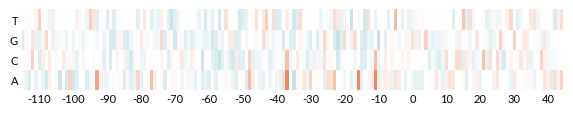

In [31]:
fig, ax = plot_exshift("araBp", '3-2', xscale=6)

In [ ]:
# Re-list inds (duplicates the cell near the top). Kept here so this section can be
# rerun standalone after restarting the kernel.
files = np.hstack([glob("../../data/extracted_barcodes/*DNA*.txt")])
inds = np.sort([x.split('/')[-1].split('_')[0] for x in files])
inds = [file for file in inds if not np.any([y == file for y in  ['14-3', '15-1', '19-1', '22-1', '25-2', '38-2','4-1', '31-2', '20-2', '13-2', '26-1', '26-2']])]


<BarContainer object of 160 artists>

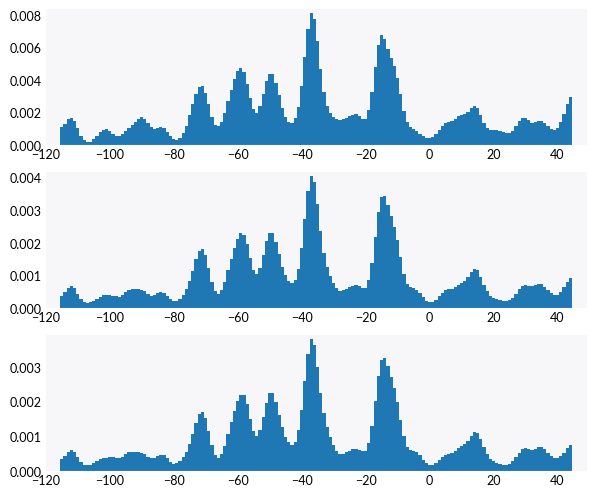

In [33]:
fig, ax = plt.subplots(3, 1, figsize=(FIG_WIDTH, 6))


x1 = compute_MI('3-1', 'araBp',transform='raw')['mut_info'].values
x2 = compute_MI('3-1', 'araBp',transform='sqrt')['mut_info'].values
x3 = compute_MI('3-1', 'araBp',transform='log1p')['mut_info'].values

ax[0].bar(np.arange(-115, 45), scipy.ndimage.gaussian_filter1d(x1, 2), width=1)
ax[1].bar(np.arange(-115, 45), scipy.ndimage.gaussian_filter1d(x2, 2), width=1)
ax[2].bar(np.arange(-115, 45), scipy.ndimage.gaussian_filter1d(x3, 2), width=1)

## Bulk computation across all samples

Loop over every QC-passing growth condition and dump per-position MI and per-base expression shift to CSV. Once these CSVs exist, the cells below can be run from cache without re-doing the computation.


In [ ]:
df_list = []
for ind in inds:
    print(ind)
    df_list.append(compute_MI(ind))

1-1
1-2
10-1
10-2
11-1
11-2
12-1
12-2
13-1
13-3
14-1
14-2
15-2
15-3
16-1
16-2
17-1
17-2
18-1
18-2
19-2
19-3
2-1
2-2
20-1
20-3
21-1
21-2
22-2
22-3
23-1
23-2
24-1
24-2
25-1
25-3
28-1
28-2
29-1
29-2
3-1
3-2
30-1
30-2
31-1
31-3
32-1
32-2
33-1
33-2
34-1
34-2
35-1
35-2
36-1
36-2
37-1
37-2
38-1
38-3
39-1
39-2
4-2
4-3
40-1
40-2
40-3
41-1
41-2
5-1
5-2
6-1
6-2
7-1
7-2
8-1
8-2
9-1
9-2


In [42]:
df_all = pd.concat(df_list).groupby(['promoter', 'N', 'ind', 'N_seqs', 'N_reads'])['mut_info'].agg('max').reset_index()
df_mi = pd.concat(df_list)
df_mi.to_csv("mi_all.csv")

In [43]:
df_list = []
for ind in inds:
    print(ind)
    df_list.append(compute_es(ind))

df_ex = pd.concat(df_list)
df_ex.to_csv("ex_all.csv")

1-1
1-2
10-1
10-2
11-1
11-2
12-1
12-2
13-1
13-3
14-1
14-2
15-2
15-3
16-1
16-2
17-1
17-2
18-1
18-2
19-2
19-3
2-1
2-2
20-1
20-3
21-1
21-2
22-2
22-3
23-1
23-2
24-1
24-2
25-1
25-3
28-1
28-2
29-1
29-2
3-1
3-2
30-1
30-2
31-1
31-3
32-1
32-2
33-1
33-2
34-1
34-2
35-1
35-2
36-1
36-2
37-1
37-2
38-1
38-3
39-1
39-2
4-2
4-3
40-1
40-2
40-3
41-1
41-2
5-1
5-2
6-1
6-2
7-1
7-2
8-1
8-2
9-1
9-2


In [45]:
df_mi = pd.read_csv("mi_all.csv", index_col=0)
df_ex = pd.read_csv("ex_all.csv", index_col=0)

relabel = True
if relabel == True: 
    df_mi['ind'] = df_mi['ind'].replace({'20-1': '30-1', '30-1': '20-1'})
    df_ex['ind'] = df_ex['ind'].replace({'20-1': '30-1', '30-1': '20-1'})

## Background MI scales as `a/N`

For non-regulatory positions the per-position MI decays as `a / N` (`N` = number of distinct barcodes for that promoter) due to finite-sample noise. Fit `a` on a panel of promoters with no expected regulation, then subtract `a / N` from MI before plotting footprints.


In [ ]:
# Promoters expected to carry no detectable regulatory signal at this depth: the
# decay of their max-MI with N traces out the finite-sample MI floor.
tss_names = {
    "TSS_1414_storz_regulondb": 'pr_yahMp',
    'TSS_18061_regulondb': 'pr_yjjJp',
    'TSS_4654_wanner_regulondb': 'pr_ymfJp',
    'TSS_4655_regulondb': 'pr_ymfJp2',
    'TSS_6311_regulondb': 'pr_dicAp',
    'ygfM_xdhD_predicted': 'pr_ygfMp',
    'ratA_yfjF_predicted': 'pr_ratAp',
    'hyuA_predicted': 'pr_hyuAp',
    'tabA_predicted': 'pr_tabAp',
    'ygeW_predicted': 'pr_ygeWp',
    'ygeY_predicted': 'pr_ygeYp',


}
proms = [
    'TSS_18061_regulondb',
    'TSS_4654_wanner_regulondb',
    'TSS_4655_regulondb',
    'TSS_6311_regulondb',
    'acrBp',
    'ygfM_xdhD_predicted',
    'ratA_yfjF_predicted',
    'hyuA_predicted',
    'tabA_predicted',
    'ygeW_predicted',
    'ygeY_predicted'
    ]#, 'ygfS_ygfT_predicted']



_df = df_all[[x in proms for x in df_all['promoter']]]
fig, ax = plt.subplots(figsize=(7, 3))

# Fit MI ≈ a / N. We solve A * a = y in least squares, where A is the column 1/N.
# `a` (a scalar here) is then used as the background MI to subtract in footprint plots below.
x = _df['N'].values
y = _df['mut_info'].values
A = (1/x)[:, np.newaxis]
a, residuals, rank, s = np.linalg.lstsq(A, y, rcond=None)
ax.plot(np.sort(x), a[0]/np.sort(x), color='gray', linewidth=2, label=r'$a/N$')

colors = [regseq2.viz.my_color_dict['blue1'],
          regseq2.viz.my_color_dict['orange1'],
          regseq2.viz.my_color_dict['green1'],
          regseq2.viz.my_color_dict['purple1'],
          regseq2.viz.my_color_dict['red1'],
          regseq2.viz.my_color_dict['yellow1'],
          regseq2.viz.my_color_dict['blue2'],
          regseq2.viz.my_color_dict['orange2'],
          regseq2.viz.my_color_dict['green2'],
          regseq2.viz.my_color_dict['purple2'],
          regseq2.viz.my_color_dict['red2']
          ]


for (c, prom) in zip(colors, proms):
    x = _df[_df['promoter'] == prom]['N'].values
    y = _df[_df['promoter'] == prom]['mut_info'].values
    ax.scatter(x, y, alpha=0.2, color=c)

    x_mean = np.median(_df[_df['promoter'] == prom]['N'].values)
    y_mean = np.median(_df[_df['promoter'] == prom]['mut_info'].values)

    if prom in tss_names.keys():
        label=tss_names[prom]
    else:
        label=prom

    ax.scatter(x_mean, y_mean, label=label, color=c, edgecolors='black', zorder=3)
#


ax.set_ylabel(r'$\mathrm{max}\ \tilde{I}$ [bits]')
ax.set_xlabel('identified p')
#ax.set_yscale('log')
ax.legend(fontsize=8, ncols=2)
#fig.savefig('../figures/MI_N_scaling_noisy.pdf')


In [47]:
a

array([8.13907748])

## Footprint plots

Background-subtracted, Gaussian-smoothed MI bars coloured by signed expression shift. Each subsection below is a different promoter / condition group.


In [ ]:
# Footprint for tisBp: subtract the a/N background MI floor (zero-clipped), then
# Gaussian-smooth and colour each MI bar by the sign/magnitude of expression shift.
sigma = 2
fig, ax = plt.subplots(2, 1, figsize=(7, 3))

N = df_mi[df_mi['promoter'] == 'tisBp']['N'].values[0]
x = scipy.ndimage.gaussian_filter1d(np.maximum(df_mi[(df_mi['promoter'] == 'tisBp') & (df_mi['ind'] == '3-2')]['mut_info'].values -a/N, np.zeros(160)), sigma)

ax[0].bar(np.arange(-115, 45), x, width=1)

# colour each bar by aggregated expression shift at that position
df_sum = df_ex[df_ex['promoter'] == 'tisBp'].groupby(['pos'])['expression_shift'].agg(sum).reset_index()
max_abs_val = np.max(np.abs(df_sum['expression_shift'].values/3))
norm = Normalize(vmin=-max_abs_val, vmax=max_abs_val)

color = [my_cmap_mi(norm(x)) for x in df_sum['expression_shift'].values/3]
ax[1].bar(np.arange(-115, 45), x, width=1, color=color, edgecolor='gray', linewidth=0.2)


ax[0].set_xticks(np.arange(-110, 41, step=10), [])
ax[1].set_xticks(np.arange(-110, 41, step=10))
ax[1].set_xlabel("position relative to transcription start site")

ax[0].grid(True, linewidth=0.5, color="white", linestyle="--")
ax[1].grid(True, linewidth=0.5, color="white", linestyle="--")

ax[0].set_xlim(-116, 45)
ax[1].set_xlim(-116, 45)
#fig.savefig('../figures/tisBp_arabinose_footprint.pdf')


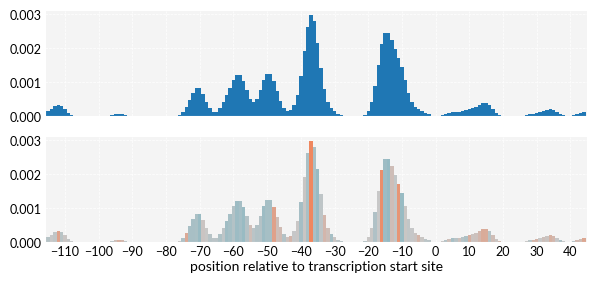

In [37]:
sigma = 2
fig, ax = plt.subplots(2, 1, figsize=(7, 3))

N = df_mi[df_mi['promoter'] == 'araBp']['N'].values[0]
x = scipy.ndimage.gaussian_filter1d(np.maximum(df_mi[df_mi['promoter'] == 'araBp']['mut_info'].values - a/N, np.zeros(160)), sigma)

ax[0].bar(np.arange(-115, 45), x, width=1)

df_sum = df_ex[df_ex['promoter'] == 'araBp'].groupby(['pos'])['expression_shift'].agg(sum).reset_index()
max_abs_val = np.max(np.abs(df_sum['expression_shift'].values/3))
norm = Normalize(vmin=-max_abs_val, vmax=max_abs_val)

color = [my_cmap_mi(norm(x)) for x in df_sum['expression_shift'].values/3]
ax[1].bar(np.arange(-115, 45), x, width=1, color=color)#, edgecolor='gray', linewidth=0.2)


ax[0].set_xticks(np.arange(-110, 41, step=10), [])
ax[1].set_xticks(np.arange(-110, 41, step=10))
ax[1].set_xlabel("position relative to transcription start site")

ax[0].grid(True, linewidth=0.5, color="white", linestyle="--")
ax[1].grid(True, linewidth=0.5, color="white", linestyle="--")

ax[0].set_xlim(-116, 45)
ax[1].set_xlim(-116, 45)
fig.savefig('../figures/araBp_arabinose_footprint.pdf')

### CpxR-related promoters


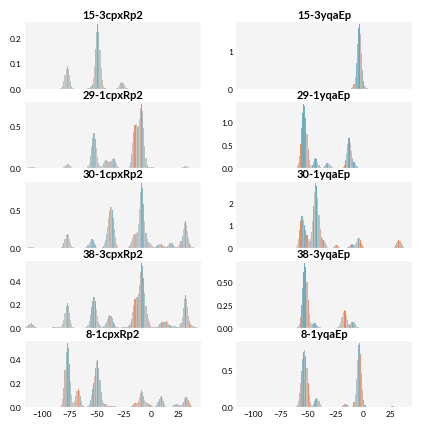

In [492]:
promoter = ['cpxRp2', 'yqaEp']
conditions = ['29-1', '30-1', '38-3', '15-3', '8-1']

df_mi_temp = df_mi[[x in promoter for x in df_mi['promoter'].values]].sort_values(by=['ind', 'promoter'])
df_mi_temp = df_mi_temp[[x in conditions for x in df_mi_temp['ind'].values]]
df_ex_temp = df_ex[[x in promoter for x in df_ex['promoter'].values]].sort_values(by=['ind', 'promoter'])
df_ex_temp = df_ex_temp[[x in conditions for x in df_ex_temp['ind'].values]]



sigma = 2
fig, ax = plt.subplots(5, 2, figsize=(5, 5), sharex=True)#, sharey=True)

n = 0
ax_arr = np.ravel(ax.T)
for i, ((prom, ), gdf) in enumerate(df_mi_temp.sort_values(by=['ind', 'promoter']).groupby(['promoter'])):
    for j, ((ind, ), ggdf) in enumerate(gdf.groupby(['ind'])):
        N = ggdf['N'].values[0]

        x = scipy.ndimage.gaussian_filter1d(np.maximum(ggdf['mut_info'].values - a/N, np.zeros(160)), sigma)

        df_sum = df_ex_temp[(df_ex_temp['promoter'] == prom) & (df_ex_temp['ind'] == ind)].groupby(['pos'])['expression_shift'].agg(sum).reset_index()
        max_abs_val = np.max(np.abs(df_sum['expression_shift'].values/3))
        norm = Normalize(vmin=-max_abs_val, vmax=max_abs_val)

        color = [my_cmap_mi(norm(x)) for x in df_sum['expression_shift'].values/3]
        ax_arr[n].bar(np.arange(-115, 45), x*1000, width=1, color=color)#, linewidth=0.1, edgecolor='#CCCCCC')
        ax_arr[n].set_xlim(-116, 45)
        ax_arr[n].tick_params(axis='both', which='major', labelsize=6)
        ax_arr[n].set_title(ind +prom)
        #ax_arr[n].set_xlim(-60, 20)
        #ax[i, j].set_xticks(np.arange(-60, 21, step=20))
        n += 1

# for i_ax, _ax in enumerate(ax.flat):
#     if i_ax // 3 != 4:  # not in last row (5 rows, index 4)
#         _ax.tick_params(axis='x', labelbottom=False)


fig.savefig(f'../figures/cpxR.pdf')

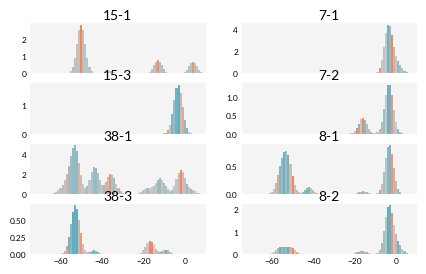

In [111]:
sigma = 2
fig, ax = plt.subplots(4, 2, figsize=(5, 3), sharex=True)#, sharey=True)

n = 0
ax_arr = np.ravel(ax.T)
for i, ((prom, ), gdf) in enumerate(df_mi_yqaE.groupby(['promoter'])):
    for j, ((ind, ), ggdf) in enumerate(gdf.groupby(['ind'])):
        N = ggdf['N'].values[0]

        x = scipy.ndimage.gaussian_filter1d(np.maximum(ggdf['mut_info'].values - a/N, np.zeros(160)), sigma)

        df_sum = df_ex_yqaE[(df_ex_yqaE['promoter'] == prom) & (df_ex_yqaE['ind'] == ind)].groupby(['pos'])['expression_shift'].agg(sum).reset_index()
        max_abs_val = np.max(np.abs(df_sum['expression_shift'].values/3))
        norm = Normalize(vmin=-max_abs_val, vmax=max_abs_val)

        color = [my_cmap_mi(norm(x)) for x in df_sum['expression_shift'].values/3]
        ax_arr[n].bar(np.arange(-115, 45), x*1000, width=1, color=color)#, linewidth=0.1, edgecolor='#CCCCCC')
        ax_arr[n].set_xlim(-116, 45)
        ax_arr[n].tick_params(axis='both', which='major', labelsize=6)
        ax_arr[n].set_title(ind)
        ax_arr[n].set_xlim(-75, 10)
        #ax[i, j].set_xticks(np.arange(-60, 21, step=20))
        n += 1

# for i_ax, _ax in enumerate(ax.flat):
#     if i_ax // 3 != 4:  # not in last row (5 rows, index 4)
#         _ax.tick_params(axis='x', labelbottom=False)


fig.savefig('../figures/yqaE_footprints.pdf')

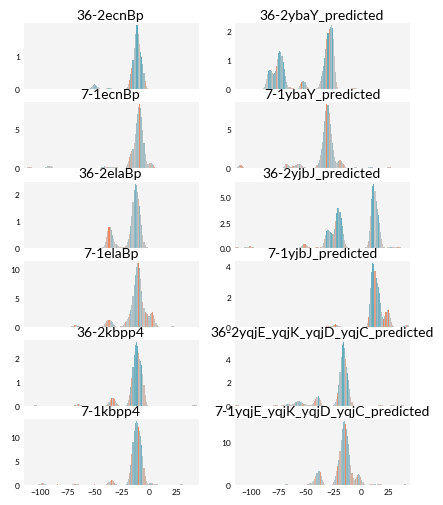

In [20]:
promoter = ['yjbJ_predicted', 'ybaY_predicted', 'yqjE_yqjK_yqjD_yqjC_predicted', 'kbpp4', 'ecnBp', 'elaBp'] 
conditions = ['7-1', '36-2']
df_mi_temp = df_mi[[x in promoter for x in df_mi['promoter'].values]].sort_values(by=['ind', 'promoter'])
df_mi_temp = df_mi_temp[[x in conditions for x in df_mi_temp['ind'].values]]
df_ex_temp = df_ex[[x in promoter for x in df_ex['promoter'].values]].sort_values(by=['ind', 'promoter'])
df_ex_temp = df_ex_temp[[x in conditions for x in df_ex_temp['ind'].values]]



sigma = 2
fig, ax = plt.subplots(6, 2, figsize=(5, 6), sharex=True)#, sharey=True)
a = 8.13
n = 0
ax_arr = np.ravel(ax.T)
for i, ((prom, ), gdf) in enumerate(df_mi_temp.sort_values(by=['ind', 'promoter']).groupby(['promoter'])):
    for j, ((ind, ), ggdf) in enumerate(gdf.groupby(['ind'])):
        N = ggdf['N'].values[0]

        x = scipy.ndimage.gaussian_filter1d(np.maximum(ggdf['mut_info'].values - a/N, np.zeros(160)), sigma)

        df_sum = df_ex_temp[(df_ex_temp['promoter'] == prom) & (df_ex_temp['ind'] == ind)].groupby(['pos'])['expression_shift'].agg(sum).reset_index()
        max_abs_val = np.max(np.abs(df_sum['expression_shift'].values/3))
        norm = Normalize(vmin=-max_abs_val, vmax=max_abs_val)

        color = [my_cmap_mi(norm(x)) for x in df_sum['expression_shift'].values/3]
        ax_arr[n].bar(np.arange(-115, 45), x*1000, width=1, color=color)#, linewidth=0.1, edgecolor='#CCCCCC')
        ax_arr[n].set_xlim(-116, 45)
        ax_arr[n].tick_params(axis='both', which='major', labelsize=6)
        ax_arr[n].set_title(ind +prom)
        #ax_arr[n].set_xlim(-60, 20)
        #ax[i, j].set_xticks(np.arange(-60, 21, step=20))
        n += 1

# for i_ax, _ax in enumerate(ax.flat):
#     if i_ax // 3 != 4:  # not in last row (5 rows, index 4)
#         _ax.tick_params(axis='x', labelbottom=False)


fig.savefig(f'../figures/salt_footprints.pdf')